In [1]:
!pip install pandas numpy matplotlib requests fredapi statsmodels xlrd yfinance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
print('Libraries have now been succesfully loaded on')
#importing all the libraries needed for the project

Libraries have now been succesfully loaded on


In [3]:
from fredapi import Fred

# Pasting my API key 
fred = Fred(api_key='2c08fc7f2fc3b31eeb069daeaf53f192')

# Pull Henry Hub Natural Gas Spot Price
# MHHNGSP = Monthly Henry Hub Natural Gas Spot Price
henry_hub = fred.get_series('MHHNGSP', observation_start='2000-01-01')

# Convert to a DataFrame and name the column
df = henry_hub.to_frame(name='price_usd_mmbtu')

print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")

            price_usd_mmbtu
2000-01-01             2.42
2000-02-01             2.66
2000-03-01             2.79
2000-04-01             3.04
2000-05-01             3.59
2000-06-01             4.29
2000-07-01             3.99
2000-08-01             4.43
2000-09-01             5.06
2000-10-01             5.02

Shape: (318, 1)
Date range: 2000-01-01 00:00:00 to 2026-06-01 00:00:00


In [4]:
# Check to find and clean missing values
print("Missing values:", df['price_usd_mmbtu'].isna().sum())

# Drop any missing rows
df = df.dropna()

# Make sure dates are in order
df = df.sort_index()

print(f"\nClean dataset: {len(df)} monthly observations")
print(df.tail(5))

Missing values: 0

Clean dataset: 318 monthly observations
            price_usd_mmbtu
2026-02-01             3.62
2026-03-01             3.04
2026-04-01             2.77
2026-05-01             2.94
2026-06-01             3.15


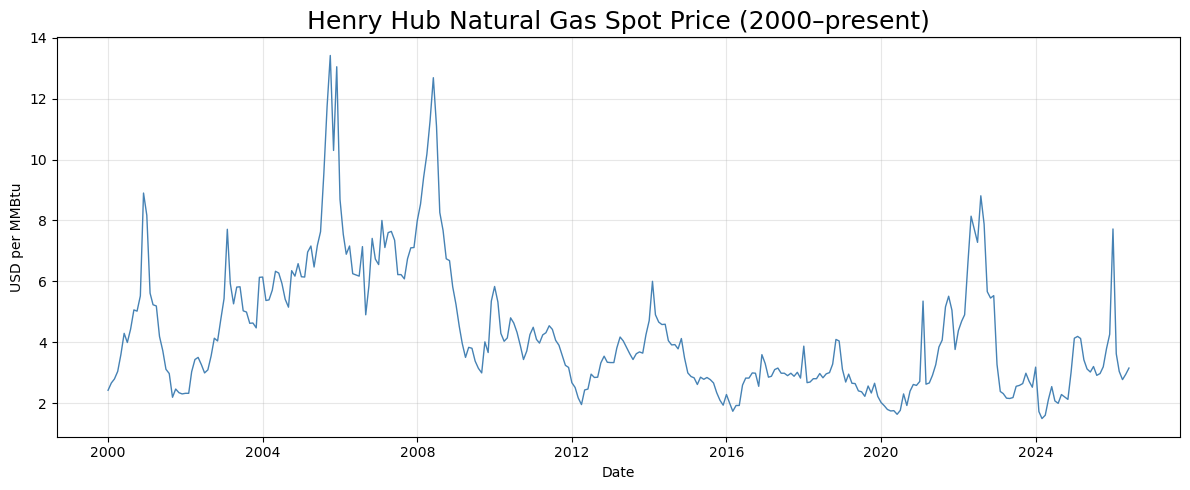

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df['price_usd_mmbtu'], color='steelblue', linewidth=1)

ax.set_title('Henry Hub Natural Gas Spot Price (2000–present)', fontsize=18)
ax.set_xlabel('Date')
ax.set_ylabel('USD per MMBtu')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Compute log returns
df['log_return'] = np.log(df['price_usd_mmbtu'] / df['price_usd_mmbtu'].shift(1))

# Drop the first row which will be NaN (no previous price to compare)
df_returns = df.dropna()

print(df_returns[['price_usd_mmbtu', 'log_return']].head(10))

            price_usd_mmbtu  log_return
2000-02-01             2.66    0.094559
2000-03-01             2.79    0.047715
2000-04-01             3.04    0.085816
2000-05-01             3.59    0.166295
2000-06-01             4.29    0.178135
2000-07-01             3.99   -0.072496
2000-08-01             4.43    0.104608
2000-09-01             5.06    0.132967
2000-10-01             5.02   -0.007937
2000-11-01             5.52    0.094948


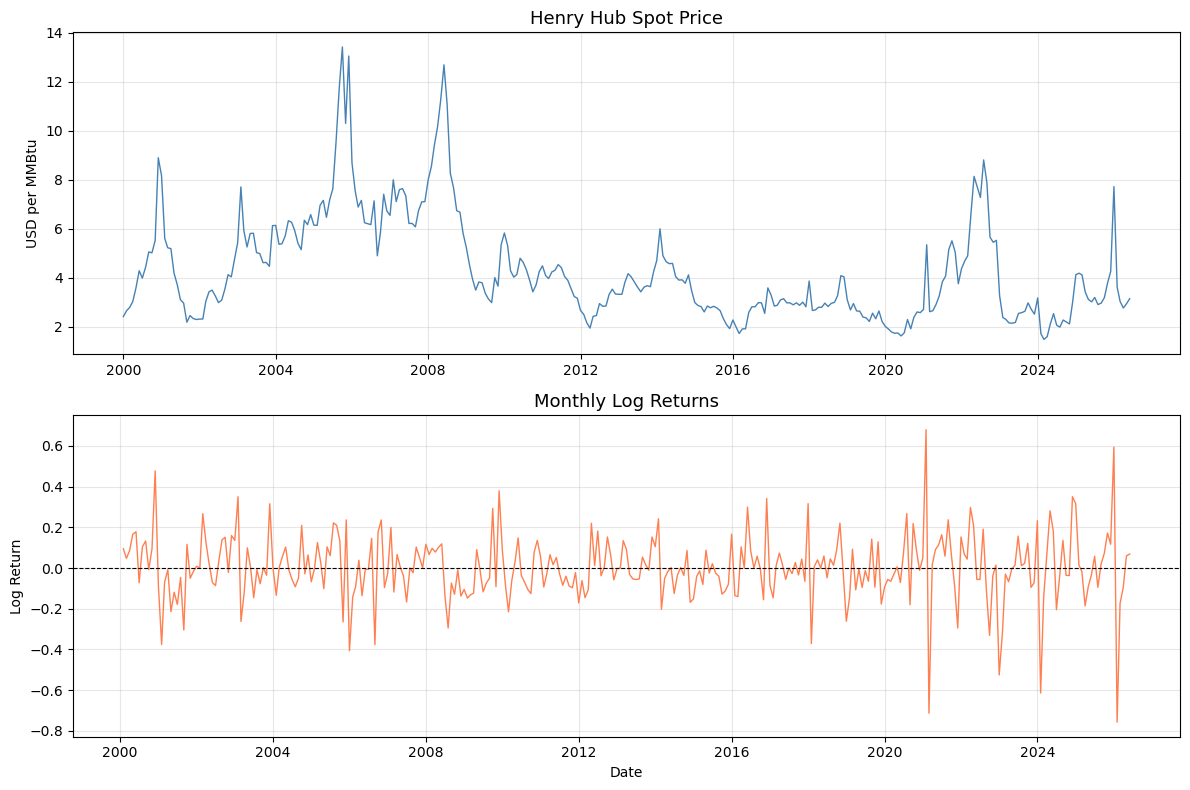

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top chart: price
axes[0].plot(df.index, df['price_usd_mmbtu'], color='steelblue', linewidth=1)
axes[0].set_title('Henry Hub Spot Price', fontsize=13)
axes[0].set_ylabel('USD per MMBtu')
axes[0].grid(True, alpha=0.3)

# Bottom chart: log returns
axes[1].plot(df_returns.index, df_returns['log_return'], color='coral', linewidth=1)
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Monthly Log Returns', fontsize=13)
axes[1].set_ylabel('Log Return')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
stats = df_returns['log_return'].describe()

# Add skewness and kurtosis manually as describe() doesn't include them
skewness = df_returns['log_return'].skew()
kurtosis = df_returns['log_return'].kurtosis()

print("=== Descriptive Statistics: Log Returns ===")
print(stats)
print(f"\nSkewness:  {skewness:.4f}")
print(f"Kurtosis:  {kurtosis:.4f}")
print(f"\nAnnualised volatility: {df_returns['log_return'].std() * np.sqrt(12):.4f}")

=== Descriptive Statistics: Log Returns ===
count    317.000000
mean       0.000832
std        0.162574
min       -0.757340
25%       -0.084230
50%       -0.003781
75%        0.088057
max        0.680148
Name: log_return, dtype: float64

Skewness:  -0.3460
Kurtosis:  4.1771

Annualised volatility: 0.5632


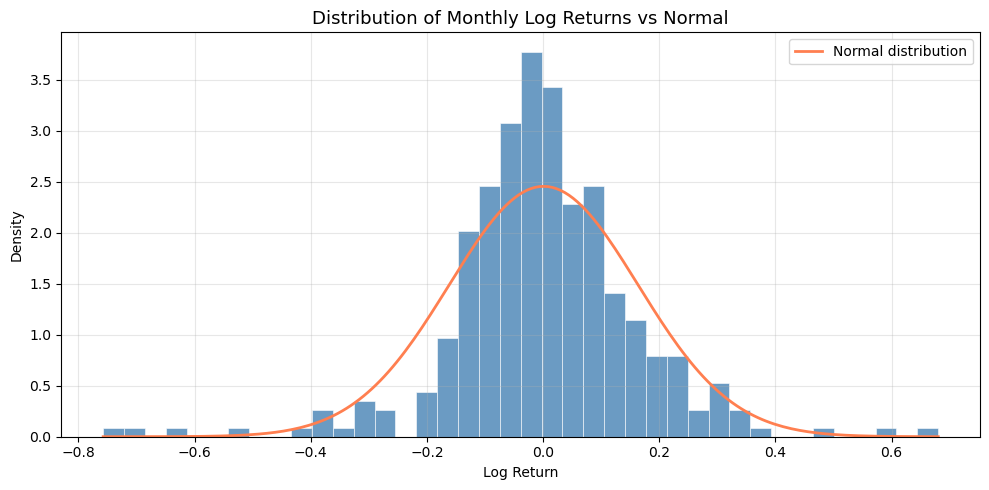

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_returns['log_return'], bins=40, color='steelblue', 
        edgecolor='white', linewidth=0.5, density=True, alpha=0.8)

# Overlay a normal distribution for comparison
from scipy import stats as scipy_stats
x = np.linspace(df_returns['log_return'].min(), df_returns['log_return'].max(), 200)
normal_pdf = scipy_stats.norm.pdf(x, df_returns['log_return'].mean(), 
                                   df_returns['log_return'].std())
ax.plot(x, normal_pdf, color='coral', linewidth=2, label='Normal distribution')

ax.set_title('Distribution of Monthly Log Returns vs Normal', fontsize=13)
ax.set_xlabel('Log Return')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

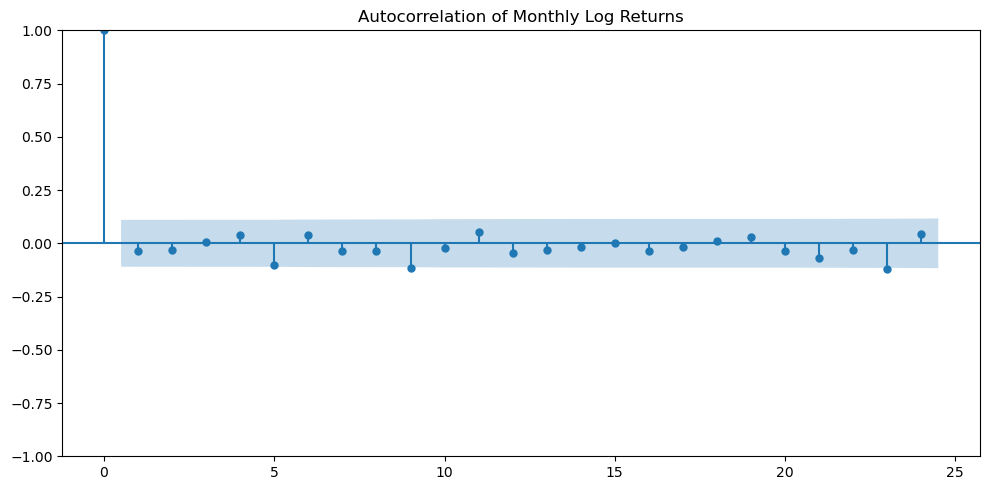

In [10]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(df_returns['log_return'], lags=24, ax=ax)
ax.set_title('Autocorrelation of Monthly Log Returns')
plt.tight_layout()
plt.show()

In [11]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['price_usd_mmbtu'].dropna())

print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

ADF Statistic: -3.6326
p-value: 0.0052
Critical Values:
   1%: -3.4511
   5%: -2.8707
   10%: -2.5717


In [12]:
EIA_API_KEY = 'MdaVcGYFsWe1TdQn8DnVdsqcGDLSKp6KIoRV02EL'
url3 = (
    f'https://api.eia.gov/v2/natural-gas/stor/wkly/data/'
    f'?api_key={EIA_API_KEY}'
    f'&frequency=weekly'
    f'&data[0]=value'
    f'&facets[duoarea][]=R48'
    f'&facets[process][]=SWO'
    f'&start=2000-01-01'
    f'&sort[0][column]=period'
    f'&sort[0][direction]=asc'
    f'&length=2000'
)

response3 = requests.get(url3)
data3 = response3.json()

storage_df = pd.DataFrame(data3['response']['data'])
storage_df['period'] = pd.to_datetime(storage_df['period'])
storage_df = storage_df.set_index('period')
storage_df = storage_df[['value']].rename(columns={'value': 'storage_bcf'})
storage_df['storage_bcf'] = pd.to_numeric(storage_df['storage_bcf'], errors='coerce')
storage_df = storage_df.dropna().sort_index()

print(storage_df.head(10))
print(f"Shape: {storage_df.shape}")
print(f"Date range: {storage_df.index[0]} to {storage_df.index[-1]}")

            storage_bcf
period                 
2010-01-01         3117
2010-01-08         2850
2010-01-15         2607
2010-01-22         2521
2010-01-29         2406
2010-02-05         2214
2010-02-12         2026
2010-02-19         1853
2010-02-26         1738
2010-03-05         1627
Shape: (863, 1)
Date range: 2010-01-01 00:00:00 to 2026-07-10 00:00:00


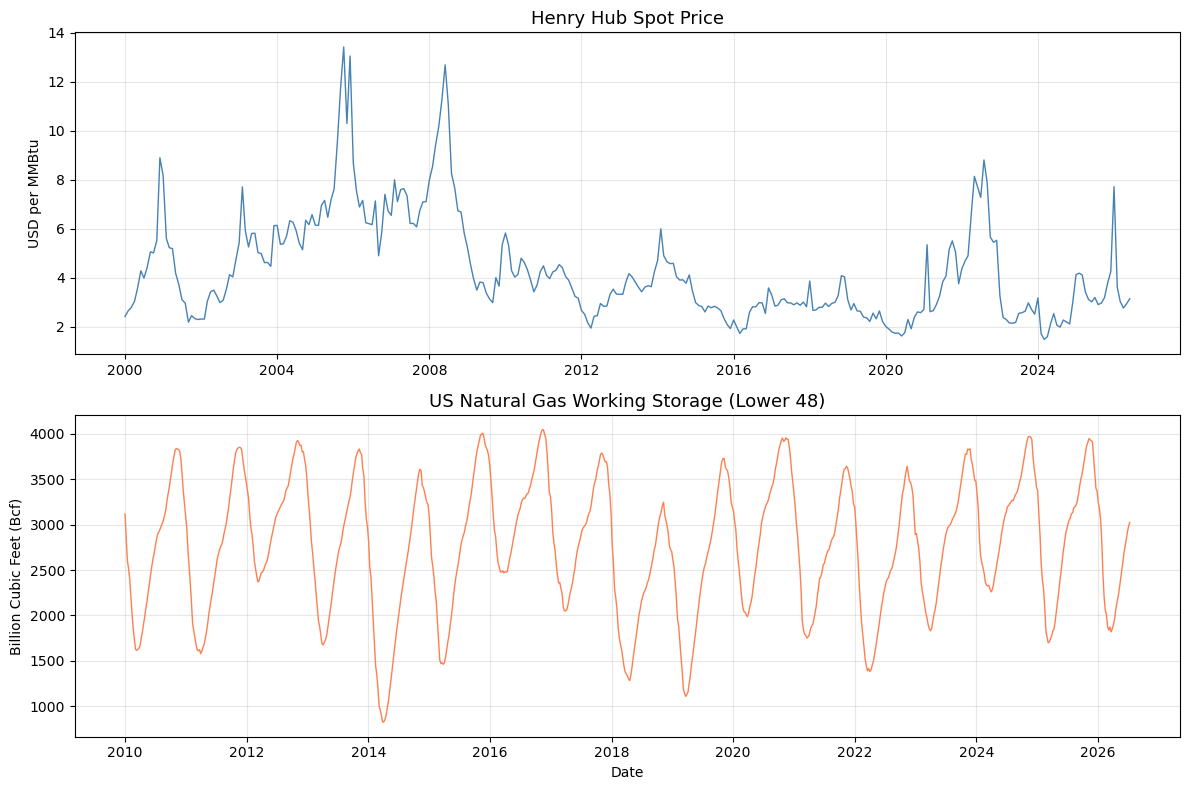

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Top: Henry Hub price
axes[0].plot(df.index, df['price_usd_mmbtu'], color='steelblue', linewidth=1)
axes[0].set_title('Henry Hub Spot Price', fontsize=13)
axes[0].set_ylabel('USD per MMBtu')
axes[0].grid(True, alpha=0.3)

# Bottom: Storage
axes[1].plot(storage_df.index, storage_df['storage_bcf'], color='coral', linewidth=1)
axes[1].set_title('US Natural Gas Working Storage (Lower 48)', fontsize=13)
axes[1].set_ylabel('Billion Cubic Feet (Bcf)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

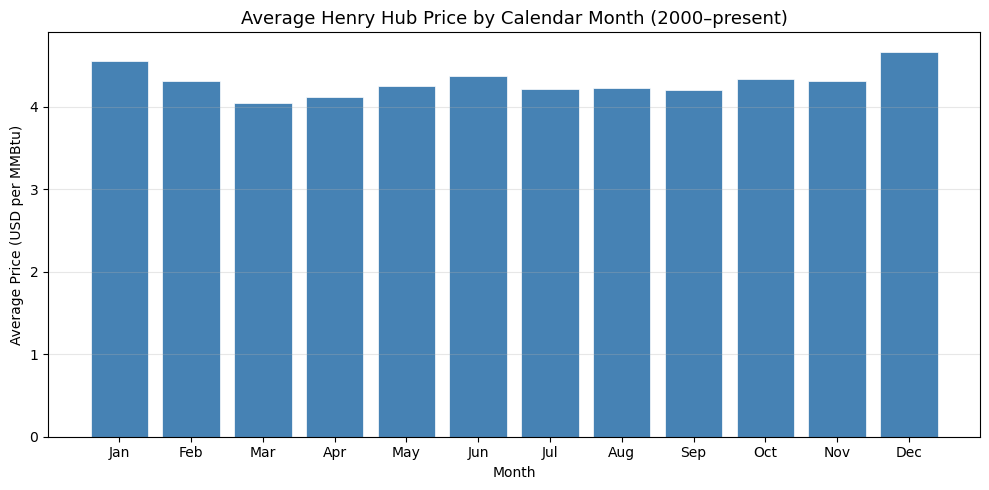

In [14]:
# Add month column to your price dataframe
df['month'] = df.index.month

# Average price by calendar month across all years
monthly_avg = df.groupby('month')['price_usd_mmbtu'].mean()

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(month_names, monthly_avg.values, color='steelblue', 
       edgecolor='white', linewidth=0.5)
ax.set_title('Average Henry Hub Price by Calendar Month (2000–present)', fontsize=13)
ax.set_ylabel('Average Price (USD per MMBtu)')
ax.set_xlabel('Month')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [15]:
#calculate mean to find mew
print(f"Mean price: {df['price_usd_mmbtu'].mean():.4f}")
print(f"Median price: {df['price_usd_mmbtu'].median():.4f}")

Mean price: 4.3033
Median price: 3.6950


In [16]:
#Phase 2 Building the model for Means Reverting using Euler-Maruyama Scheme as an approximation for SDE

In [17]:
import numpy as np

def simulate_ou(mu, kappa, sigma, P0, T, dt, n_paths):
    """
    Simulate price paths using Euler-Maruyama discretisation
    of the Ornstein-Uhlenbeck process.
    
    Parameters:
    mu     : long-run mean price
    kappa  : mean reversion speed
    sigma  : volatility
    P0     : starting price
    T      : total time in years
    dt     : time step in years
    n_paths: number of simulated paths
    """
    n_steps = int(T / dt)
    paths = np.zeros((n_steps + 1, n_paths))
    paths[0] = P0
    
    for t in range(1, n_steps + 1):
        Z = np.random.standard_normal(n_paths)
        paths[t] = (paths[t-1] 
                   + kappa * (mu - paths[t-1]) * dt 
                   + sigma * np.sqrt(dt) * Z)
    
    return paths

# Using  our Phase 1 estimates as starting parameters
mu    = 4.23    # long-run mean (USD/MMBtu)
kappa = 0.5    # placeholder — we'll calibrate this properly next
sigma = 0.56    # annualised volatility from Phase 1
P0    = df['price_usd_mmbtu'].iloc[-1]  # start from most recent price
T     = 5       # simulate 5 years forward
dt    = 1/12    # monthly time steps

# Run simulation
np.random.seed(42)  # for reproducibility
paths = simulate_ou(mu, kappa, sigma, P0, T, dt, n_paths=100)

print(f"Simulation shape: {paths.shape}")
print(f"Starting price: ${P0:.2f}")
print(f"Time steps: {int(T/dt)} months")

Simulation shape: (61, 100)
Starting price: $3.15
Time steps: 60 months


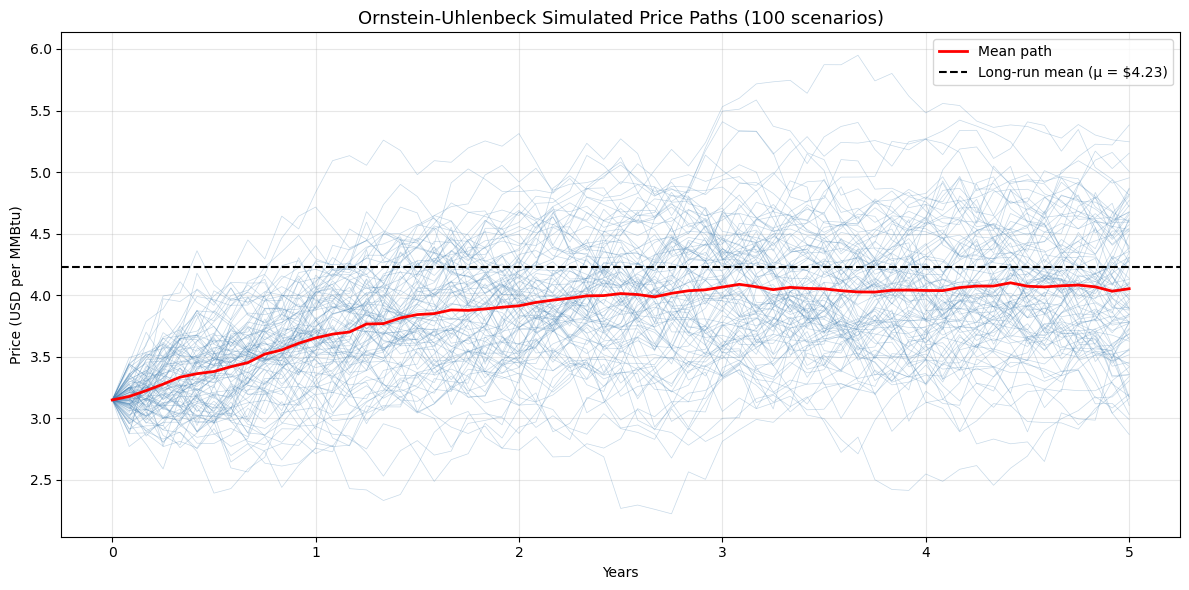

In [18]:
time_axis = np.linspace(0, T, int(T/dt) + 1)

fig, ax = plt.subplots(figsize=(12, 6))

# Plot all simulated paths in light blue
for i in range(100):
    ax.plot(time_axis, paths[:, i], color='steelblue', 
            linewidth=0.5, alpha=0.3)

# Plot the mean path across all simulations
ax.plot(time_axis, paths.mean(axis=1), color='red', 
        linewidth=2, label='Mean path')

# Plot the long-run mean as a reference line
ax.axhline(y=mu, color='black', linewidth=1.5, 
           linestyle='--', label=f'Long-run mean (μ = ${mu})')

ax.set_title('Ornstein-Uhlenbeck Simulated Price Paths (100 scenarios)', fontsize=13)
ax.set_xlabel('Years')
ax.set_ylabel('Price (USD per MMBtu)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('simulated_paths.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
from scipy.optimize import minimize
from scipy.stats import norm

def ou_log_likelihood(params, prices, dt):
    """
    Compute negative log-likelihood for OU process.
    We minimise the negative because scipy minimises by default.
    
    params : [kappa, mu, sigma]
    prices : array of observed prices
    dt     : time step in years
    """
    kappa, mu, sigma = params
    
    # Prevent invalid parameter values
    if kappa <= 0 or sigma <= 0:
        return 1e10
    
    # Expected next price and variance under OU
    P_current = prices[:-1]
    P_next    = prices[1:]
    
    expected  = P_current + kappa * (mu - P_current) * dt
    variance  = sigma**2 * dt
    
    # Log likelihood of each transition
    log_lik = norm.logpdf(P_next, loc=expected, scale=np.sqrt(variance))
    
    return -np.sum(log_lik)

# Prepare price array
prices = df['price_usd_mmbtu'].dropna().values
dt = 1/12

# Initial parameter guesses (Phase 1 estimates)
initial_params = [0.5, 4.23, 0.56]

# Run optimisation
result = minimize(
    ou_log_likelihood,
    initial_params,
    args=(prices, dt),
    method='Nelder-Mead',
    options={'maxiter': 10000}
)

kappa_fit, mu_fit, sigma_fit = result.x

print("=== Calibrated Parameters ===")
print(f"κ (mean reversion speed): {kappa_fit:.4f}")
print(f"μ (long-run mean):        ${mu_fit:.4f}")
print(f"σ (volatility):           {sigma_fit:.4f}")
print(f"\nAnnualised volatility:    {sigma_fit * np.sqrt(12):.4f}")
print(f"Optimisation success:     {result.success}")

=== Calibrated Parameters ===
κ (mean reversion speed): 0.9555
μ (long-run mean):        $4.3358
σ (volatility):           2.8652

Annualised volatility:    9.9253
Optimisation success:     True


In [20]:
from scipy.optimize import minimize

def ou_log_likelihood(params, prices, dt):
    kappa, mu, sigma = params
    if kappa <= 0 or sigma <= 0:
        return 1e10
    P_current = prices[:-1]
    P_next    = prices[1:]
    expected  = P_current + kappa * (mu - P_current) * dt
    variance  = sigma**2 * dt
    log_lik   = norm.logpdf(P_next, loc=expected, scale=np.sqrt(variance))
    return -np.sum(log_lik)

prices = df['price_usd_mmbtu'].dropna().values
dt = 1/12

initial_params = [0.5, 4.23, 0.56]

# Add bounds: kappa in (0,10), mu in (1,10), sigma in (0.01, 2)
bounds = [(0.01, 10), (1.0, 10.0), (0.01, 2.0)]

result = minimize(
    ou_log_likelihood,
    initial_params,
    args=(prices, dt),
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 10000}
)

kappa_fit, mu_fit, sigma_fit = result.x

print("=== Calibrated Parameters ===")
print(f"κ (mean reversion speed): {kappa_fit:.4f}")
print(f"μ (long-run mean):        ${mu_fit:.4f}")
print(f"σ (volatility):           {sigma_fit:.4f}")
print(f"\nAnnualised volatility:    {sigma_fit * np.sqrt(12):.4f}")
print(f"Optimisation success:     {result.success}")

=== Calibrated Parameters ===
κ (mean reversion speed): 0.9556
μ (long-run mean):        $4.3358
σ (volatility):           2.0000

Annualised volatility:    6.9282
Optimisation success:     True


In [21]:
from scipy.optimize import minimize
from scipy.stats import norm

# Work in log price space
log_prices = np.log(df['price_usd_mmbtu'].dropna().values)
dt = 1/12

def ou_log_likelihood(params, log_prices, dt):
    kappa, mu_log, sigma = params
    if kappa <= 0 or sigma <= 0:
        return 1e10
    
    P_current = log_prices[:-1]
    P_next    = log_prices[1:]
    
    expected  = P_current + kappa * (mu_log - P_current) * dt
    variance  = sigma**2 * dt
    
    log_lik   = norm.logpdf(P_next, loc=expected, scale=np.sqrt(variance))
    return -np.sum(log_lik)

initial_params = [0.5, np.log(4.23), 0.56]
bounds = [(0.01, 10), (0.0, 5.0), (0.01, 2.0)]

result = minimize(
    ou_log_likelihood,
    initial_params,
    args=(log_prices, dt),
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 10000}
)

kappa_fit, mu_log_fit, sigma_fit = result.x

# Convert mu back from log space to price space
mu_fit = np.exp(mu_log_fit)

print("=== Calibrated Parameters ===")
print(f"κ (mean reversion speed): {kappa_fit:.4f}")
print(f"μ (long-run mean):        ${mu_fit:.4f}")
print(f"σ (volatility):           {sigma_fit:.4f}")
print(f"\nAnnualised volatility:    {sigma_fit * np.sqrt(12):.4f}")
print(f"Optimisation success:     {result.success}")

=== Calibrated Parameters ===
κ (mean reversion speed): 0.8105
μ (long-run mean):        $3.9284
σ (volatility):           0.5525

Annualised volatility:    1.9139
Optimisation success:     True


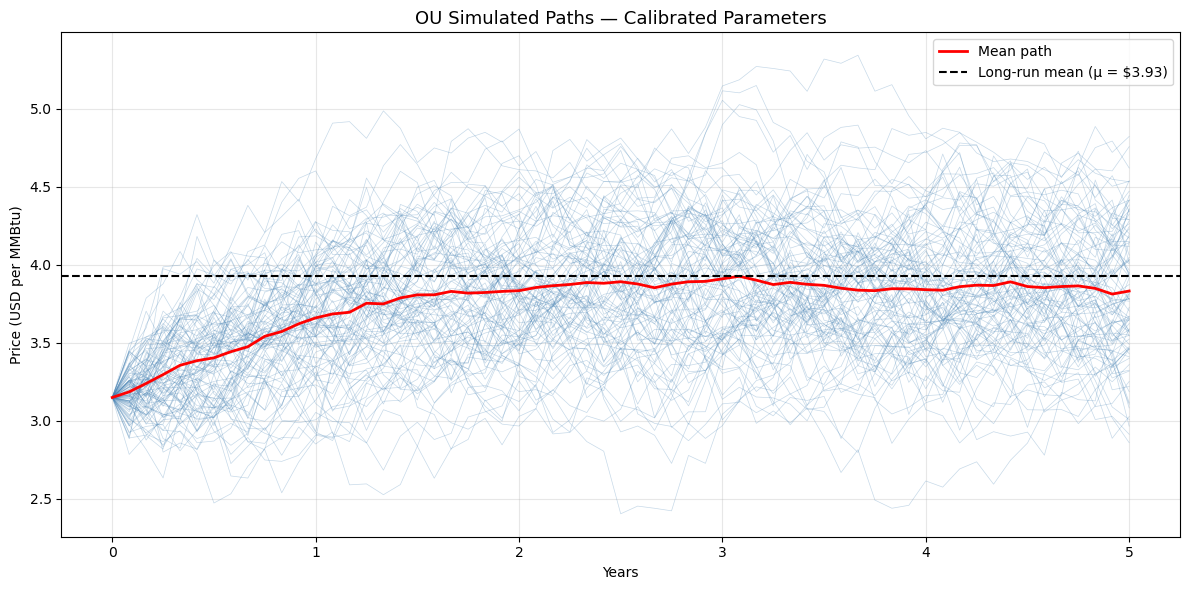

In [22]:
# Resimulate using calibrated parameters
np.random.seed(42)

paths_calibrated = simulate_ou(
    mu    = mu_fit,
    kappa = kappa_fit,
    sigma = sigma_fit,
    P0    = df['price_usd_mmbtu'].iloc[-1],
    T     = 5,
    dt    = 1/12,
    n_paths = 100
)

time_axis = np.linspace(0, 5, int(5/(1/12)) + 1)

fig, ax = plt.subplots(figsize=(12, 6))

for i in range(100):
    ax.plot(time_axis, paths_calibrated[:, i], 
            color='steelblue', linewidth=0.5, alpha=0.3)

ax.plot(time_axis, paths_calibrated.mean(axis=1), 
        color='red', linewidth=2, label='Mean path')

ax.axhline(y=mu_fit, color='black', linewidth=1.5,
           linestyle='--', label=f'Long-run mean (μ = ${mu_fit:.2f})')

ax.set_title('OU Simulated Paths — Calibrated Parameters', fontsize=13)
ax.set_xlabel('Years')
ax.set_ylabel('Price (USD per MMBtu)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('simulated_paths.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Compare simulated vs historical statistics
sim_final_prices = paths_calibrated[-1, :]
sim_returns = np.diff(np.log(paths_calibrated), axis=0).flatten()
hist_returns = df_returns['log_return'].values

print("=== Model Validation ===")
print(f"{'Metric':<25} {'Historical':>12} {'Simulated':>12}")
print("-" * 50)
print(f"{'Mean log return':<25} {hist_returns.mean():>12.4f} {sim_returns.mean():>12.4f}")
print(f"{'Std log return':<25} {hist_returns.std():>12.4f} {sim_returns.std():>12.4f}")
print(f"{'Skewness':<25} {pd.Series(hist_returns).skew():>12.4f} {pd.Series(sim_returns).skew():>12.4f}")
print(f"{'Kurtosis':<25} {pd.Series(hist_returns).kurtosis():>12.4f} {pd.Series(sim_returns).kurtosis():>12.4f}")
print(f"{'Min price (5yr)':<25} {'N/A':>12} {sim_final_prices.min():>12.4f}")
print(f"{'Max price (5yr)':<25} {'N/A':>12} {sim_final_prices.max():>12.4f}")

=== Model Validation ===
Metric                      Historical    Simulated
--------------------------------------------------
Mean log return                 0.0008       0.0032
Std log return                  0.1623       0.0442
Skewness                       -0.3460       0.0259
Kurtosis                        4.1771       0.2192
Min price (5yr)                    N/A       2.8600
Max price (5yr)                    N/A       4.8238


In [24]:
#Phase 3

In [25]:
def monte_carlo_option(mu, kappa, sigma, P0, K, T, r, dt, n_paths):
    """
    Price a European call option using Monte Carlo simulation
    under the Ornstein-Uhlenbeck / Schwartz one-factor model.
    
    mu     : long-run mean price
    kappa  : mean reversion speed
    sigma  : volatility
    P0     : current price
    K      : strike price
    T      : time to expiry in years
    r      : risk-free rate
    dt     : time step in years
    n_paths: number of simulated paths
    """
    # Simulate price paths
    paths = simulate_ou(mu, kappa, sigma, P0, T, dt, n_paths)
    
    # Extract prices at expiry (final row)
    prices_at_expiry = paths[-1, :]
    
    # Compute call option payoffs
    payoffs = np.maximum(prices_at_expiry - K, 0)
    
    # Discount back to today
    option_price = np.exp(-r * T) * np.mean(payoffs)
    
    # Fraction of paths ending in the money
    in_the_money = np.mean(prices_at_expiry > K)
    
    return option_price, payoffs, prices_at_expiry, in_the_money


# Parameters
P0    = df['price_usd_mmbtu'].iloc[-1]  # current price
K     = 5.00                             # strike price
T     = 1.0                             # 1 year to expiry
r     = 0.05                            # risk-free rate (5%)
dt    = 1/12                            # monthly steps
n_paths = 10000                         # more paths = more accurate

np.random.seed(42)
option_price, payoffs, prices_at_expiry, itm = monte_carlo_option(
    mu_fit, kappa_fit, sigma_fit, P0, K, T, r, dt, n_paths
)

print(f"Current price:        ${P0:.2f}")
print(f"Strike price:         ${K:.2f}")
print(f"Time to expiry:       {T} year")
print(f"Risk-free rate:       {r*100:.1f}%")
print(f"\nOption price:         ${option_price:.4f} per MMBtu")
print(f"Paths in the money:   {itm*100:.1f}%")
print(f"Average payoff:       ${np.mean(payoffs):.4f}")

Current price:        $3.15
Strike price:         $5.00
Time to expiry:       1.0 year
Risk-free rate:       5.0%

Option price:         $0.0000 per MMBtu
Paths in the money:   0.0%
Average payoff:       $0.0000


In [26]:
# Price options across a range of strikes
strikes = [3.00, 3.50, 4.00, 4.50, 5.00]

print(f"Current price: ${P0:.2f}")
print(f"\n{'Strike':>8} {'Option Price':>14} {'In the Money':>14}")
print("-" * 40)

np.random.seed(42)
for K in strikes:
    price, _, _, itm = monte_carlo_option(
        mu_fit, kappa_fit, sigma_fit, P0, K, T, r, dt, n_paths=10000
    )
    print(f"${K:>6.2f} {price:>13.4f} {itm*100:>13.1f}%")

Current price: $3.15

  Strike   Option Price   In the Money
----------------------------------------
$  3.00        0.5781          93.1%
$  3.50        0.1980          59.2%
$  4.00        0.0294          15.2%
$  4.50        0.0016           1.2%
$  5.00        0.0000           0.0%


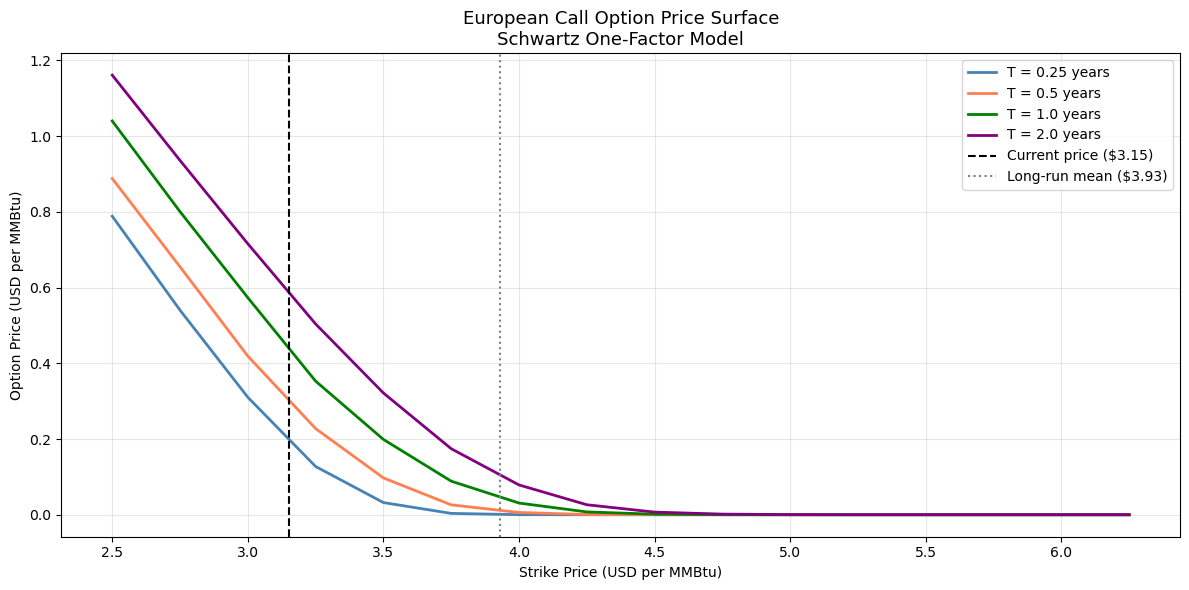

In [27]:

strikes = np.arange(2.50, 6.50, 0.25)
expiries = [0.25, 0.5, 1.0, 2.0]
colors = ['steelblue', 'coral', 'green', 'purple']

fig, ax = plt.subplots(figsize=(12, 6))

np.random.seed(42)
for T_exp, color in zip(expiries, colors):
    prices = []
    for K in strikes:
        p, _, _, _ = monte_carlo_option(
            mu_fit, kappa_fit, sigma_fit,
            P0, K, T_exp, r, dt, n_paths=5000
        )
        prices.append(p)
    ax.plot(strikes, prices, color=color, 
            linewidth=2, label=f'T = {T_exp} years')

ax.axvline(x=P0, color='black', linewidth=1.5,
           linestyle='--', label=f'Current price (${P0:.2f})')
ax.axvline(x=mu_fit, color='gray', linewidth=1.5,
           linestyle=':', label=f'Long-run mean (${mu_fit:.2f})')

ax.set_title('European Call Option Price Surface\nSchwartz One-Factor Model', 
             fontsize=13)
ax.set_xlabel('Strike Price (USD per MMBtu)')
ax.set_ylabel('Option Price (USD per MMBtu)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('option_price_surface.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
#Phase 4

In [29]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pull front-month and next-month natural gas futures
# NG=F is the front-month NYMEX natural gas futures contract
ng_front = yf.download('NG=F', start='2010-01-01', progress=False)
ng_front = ng_front['Close'].resample('MS').last()
ng_front.name = 'front_month'

print(f"Front-month futures shape: {ng_front.shape}")
print(f"Date range: {ng_front.index[0]} to {ng_front.index[-1]}")
print(f"\nMost recent 5 observations:")
print(ng_front.tail())

Front-month futures shape: (199, 1)
Date range: 2010-01-01 00:00:00 to 2026-07-01 00:00:00

Most recent 5 observations:
Ticker       NG=F
Date             
2026-03-01  2.884
2026-04-01  2.767
2026-05-01  3.290
2026-06-01  3.275
2026-07-01  2.885


In [30]:
# Merge spot and futures prices
ng_front = yf.download('NG=F', start='2010-01-01', progress=False)
ng_front = ng_front['Close'].resample('MS').last()

# Add this line to flatten from (199,1) to (199,)
ng_front = ng_front.squeeze()
ng_front.name = 'front_month'

print(f"Front-month futures shape: {ng_front.shape}")
print(ng_front.tail())

spot = df['price_usd_mmbtu'].resample('MS').last()
spot.name = 'spot'

# Align both series on common dates
combined = pd.DataFrame({'spot': spot, 'futures': ng_front}).dropna()

print(f"Combined shape: {combined.shape}")
print(f"Date range: {combined.index[0]} to {combined.index[-1]}")
print(f"\nMost recent 5 observations:")
print(combined.tail())

Front-month futures shape: (199,)
Date
2026-03-01    2.884
2026-04-01    2.767
2026-05-01    3.290
2026-06-01    3.275
2026-07-01    2.885
Freq: MS, Name: front_month, dtype: float64
Combined shape: (198, 2)
Date range: 2010-01-01 00:00:00 to 2026-06-01 00:00:00

Most recent 5 observations:
            spot  futures
2026-02-01  3.62    2.859
2026-03-01  3.04    2.884
2026-04-01  2.77    2.767
2026-05-01  2.94    3.290
2026-06-01  3.15    3.275


In [31]:
# Parameters for convenience yield calculation
r = 0.05   # risk-free rate (5%)
c = 0.02   # storage cost (2% per year, typical for natural gas)
T = 1/12   # one month forward

# Compute implied convenience yield from cost-of-carry formula
# cy = r + c - (1/T) * ln(F/S)
combined['cy'] = (r + c 
                  - (1/T) * np.log(combined['futures'] / combined['spot']))

# Add month column for seasonality analysis
combined['month'] = combined.index.month

print(combined[['spot', 'futures', 'cy']].tail(10))
print(f"\nMean convenience yield: {combined['cy'].mean():.4f}")
print(f"Max convenience yield:  {combined['cy'].max():.4f}")
print(f"Min convenience yield:  {combined['cy'].min():.4f}")

            spot  futures        cy
2025-09-01  2.97    3.303 -1.205230
2025-10-01  3.19    4.124 -3.011632
2025-11-01  3.79    4.850 -2.889352
2025-12-01  4.26    3.686  1.806727
2026-01-01  7.72    4.354  6.942633
2026-02-01  3.62    2.859  2.902025
2026-03-01  3.04    2.884  0.702151
2026-04-01  2.77    2.767  0.083004
2026-05-01  2.94    3.290 -1.279736
2026-06-01  3.15    3.275 -0.396985

Mean convenience yield: -0.0738
Max convenience yield:  7.9647
Min convenience yield:  -5.4670


In [32]:
# Merge convenience yield with storage data
# Resample storage to monthly
storage_monthly = storage_df['storage_bcf'].resample('MS').mean()

# Combine
phase4 = pd.DataFrame({
    'cy': combined['cy'],
    'storage': storage_monthly
}).dropna()

print(f"Combined shape: {phase4.shape}")
print(phase4.tail())

Combined shape: (198, 2)
                  cy  storage
2026-02-01  2.902025  2036.00
2026-03-01  0.702151  1844.75
2026-04-01  0.083004  2016.25
2026-05-01 -1.279736  2389.40
2026-06-01 -0.396985  2800.50


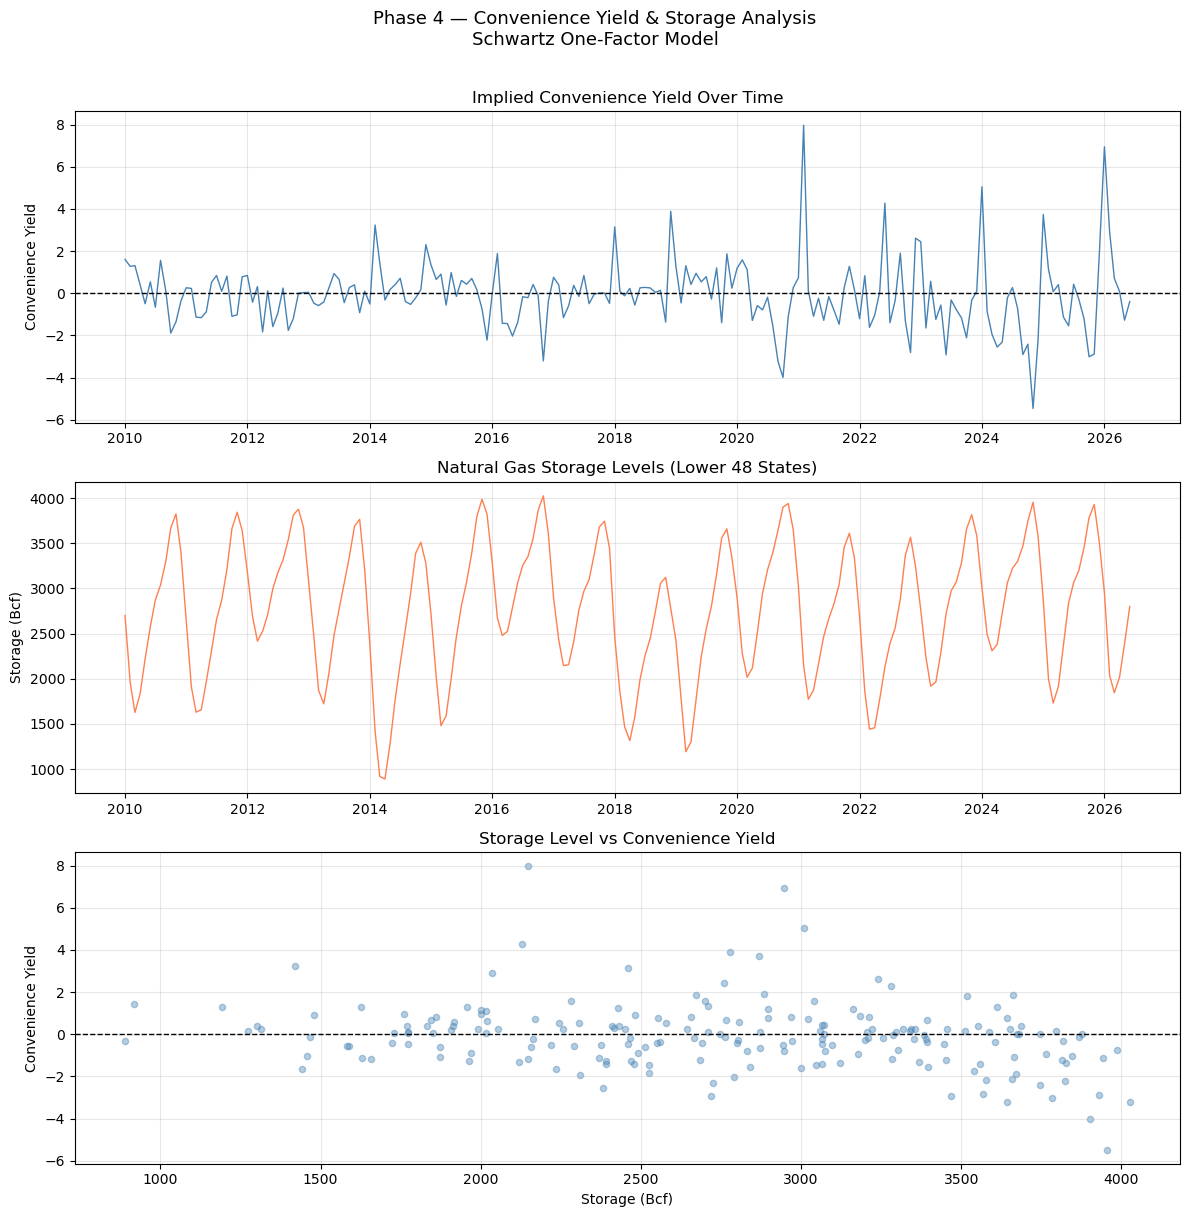

In [33]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Chart 1 — Convenience yield over time
axes[0].plot(phase4.index, phase4['cy'], 
             color='steelblue', linewidth=1)
axes[0].axhline(y=0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Implied Convenience Yield Over Time', fontsize=12)
axes[0].set_ylabel('Convenience Yield')
axes[0].grid(True, alpha=0.3)

# Chart 2 — Storage over time
axes[1].plot(phase4.index, phase4['storage'], 
             color='coral', linewidth=1)
axes[1].set_title('Natural Gas Storage Levels (Lower 48 States)', fontsize=12)
axes[1].set_ylabel('Storage (Bcf)')
axes[1].grid(True, alpha=0.3)

# Chart 3 — Scatter: storage vs convenience yield
axes[2].scatter(phase4['storage'], phase4['cy'], 
                alpha=0.4, color='steelblue', s=20)
axes[2].axhline(y=0, color='black', linewidth=1, linestyle='--')
axes[2].set_title('Storage Level vs Convenience Yield', fontsize=12)
axes[2].set_xlabel('Storage (Bcf)')
axes[2].set_ylabel('Convenience Yield')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Phase 4 — Convenience Yield & Storage Analysis\n'
             'Schwartz One-Factor Model', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('convenience_yield_storage.png', dpi=150, bbox_inches='tight')
plt.show()

Regression results:
Slope:     -0.000538
Intercept: 1.4079
R²:        0.0600
P-value:   0.0005


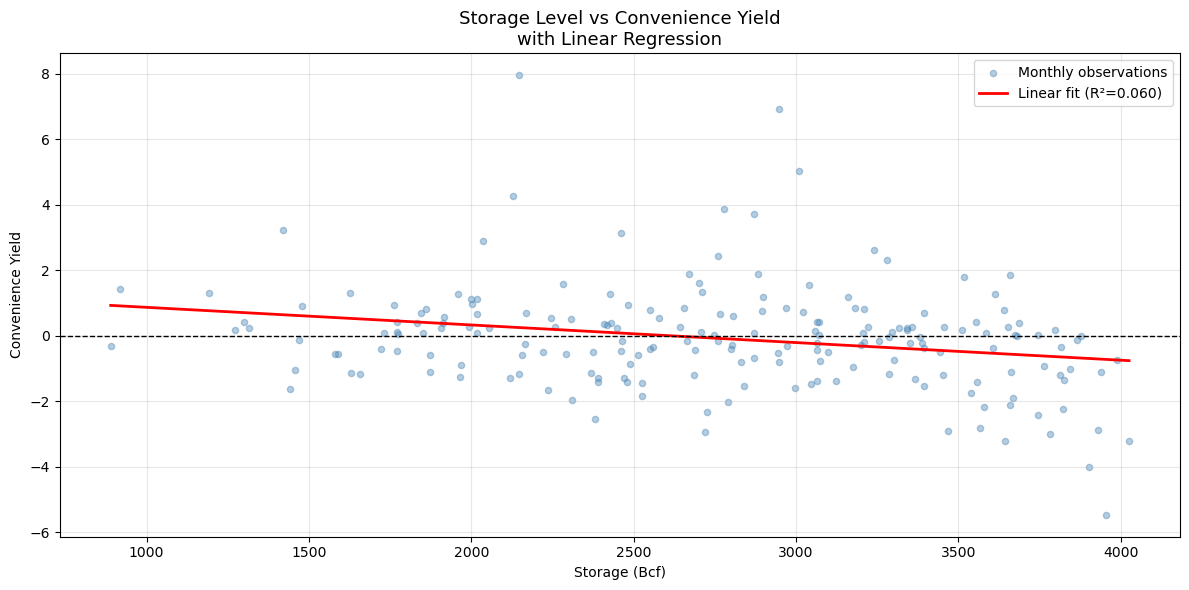

In [34]:
from scipy import stats

# Linear regression of cy on storage
slope, intercept, r_value, p_value, std_err = stats.linregress(
    phase4['storage'], phase4['cy']
)

print(f"Regression results:")
print(f"Slope:     {slope:.6f}")
print(f"Intercept: {intercept:.4f}")
print(f"R²:        {r_value**2:.4f}")
print(f"P-value:   {p_value:.4f}")

# Replot scatter with regression line
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(phase4['storage'], phase4['cy'],
           alpha=0.4, color='steelblue', s=20, label='Monthly observations')

# Regression line
x_line = np.linspace(phase4['storage'].min(), phase4['storage'].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='red', linewidth=2, label=f'Linear fit (R²={r_value**2:.3f})')

ax.axhline(y=0, color='black', linewidth=1, linestyle='--')
ax.set_title('Storage Level vs Convenience Yield\nwith Linear Regression', fontsize=13)
ax.set_xlabel('Storage (Bcf)')
ax.set_ylabel('Convenience Yield')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('storage_vs_cy.png', dpi=150, bbox_inches='tight')
plt.show()